In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob

In [2]:
SIZE = 50
EPOCHS = 50
LR = 0.001

In [3]:
def load_image(path):

    img = Image.open(path).convert("L").resize((SIZE, SIZE))

    img_array = np.array(img)

    data = np.where(img_array > 127, 1, -1)

    return data.flatten()


def load_dataset(folder):

    files = sorted(glob.glob(os.path.join(folder, "*.png")))

    data = [load_image(f) for f in files]

    return np.array(data)


In [4]:
def show_image(vec, title=""):

    img = vec.reshape(SIZE, SIZE)

    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)

    plt.title(title)

    plt.axis("off")

    plt.show()


In [5]:
def add_noise(x, noise_level=0.2):

    noisy = x.copy()

    mask = np.random.rand(*x.shape) < noise_level
    
    noisy[mask] *= -1

    return noisy

In [6]:
def initialize_model(input_size):

    weights = np.zeros(
        (input_size, input_size),
        dtype=np.float32
    )

    bias = np.zeros(
        input_size,
        dtype=np.float32
    )

    return weights, bias

In [7]:
def predict(inputs, weights, bias):

    activation = np.dot(inputs, weights) + bias

    output = np.where(activation >= 0, 1, -1)

    return output

In [8]:
def train_step(inputs, target, weights, bias):

    prediction = predict(
        inputs,
        weights,
        bias
    )

    error = target - prediction

    weights += (
        LR *
        np.outer(inputs, error) /
        len(inputs)
    )

    bias += LR * error

    np.fill_diagonal(weights, 0)

    weights = np.clip(
        weights,
        -1,
        1
    )

    accuracy = np.mean(
        prediction == target
    )

    errors = np.sum(error != 0)

    return weights, bias, errors, accuracy

In [9]:
def train_model(X):

    input_size = SIZE * SIZE

    weights, bias = initialize_model(
        input_size
    )

    for epoch in range(EPOCHS):

        total_errors = 0
        total_accuracy = 0

        index = np.random.permutation(
            len(X)
        )

        for idx in index:

            img = X[idx]

            noisy = add_noise(
                img,
                noise_level=0.10
            )

            weights, bias, errors, accuracy = train_step(
                noisy,
                img,
                weights,
                bias
            )

            total_errors += errors
            total_accuracy += accuracy

        avg_accuracy = total_accuracy / len(X)

        if total_errors < 10:

            print("Early stopping")
            
            print(
            f"Epoka {epoch+1} | "
            f"Błędy: {total_errors} | "
            f"Accuracy: {avg_accuracy:.4f}"
            )
            break

    return weights, bias

In [10]:
def denoise(noisy_img, weights, bias, max_steps=50):

    current = noisy_img.copy()

    history = [current.copy()]

    for step in range(max_steps):

        new_img = predict(
            current,
            weights,
            bias
        )

        history.append(new_img.copy())

        if np.array_equal(new_img, current):

            print(
                f"Stabilizacja po {step+1} krokach"
            )

            break

        current = new_img

    return current, history

In [11]:
folder = "dataset"

X = load_dataset(folder)

print("Start treningu...")

weights, bias = train_model(X)

print("Koniec treningu")

Start treningu...
Early stopping
Epoka 18 | Błędy: 8 | Accuracy: 0.9997
Koniec treningu


In [20]:
test_img = X[4]


noisy = add_noise(
    test_img,
    noise_level=0.50
)

Stabilizacja po 7 krokach


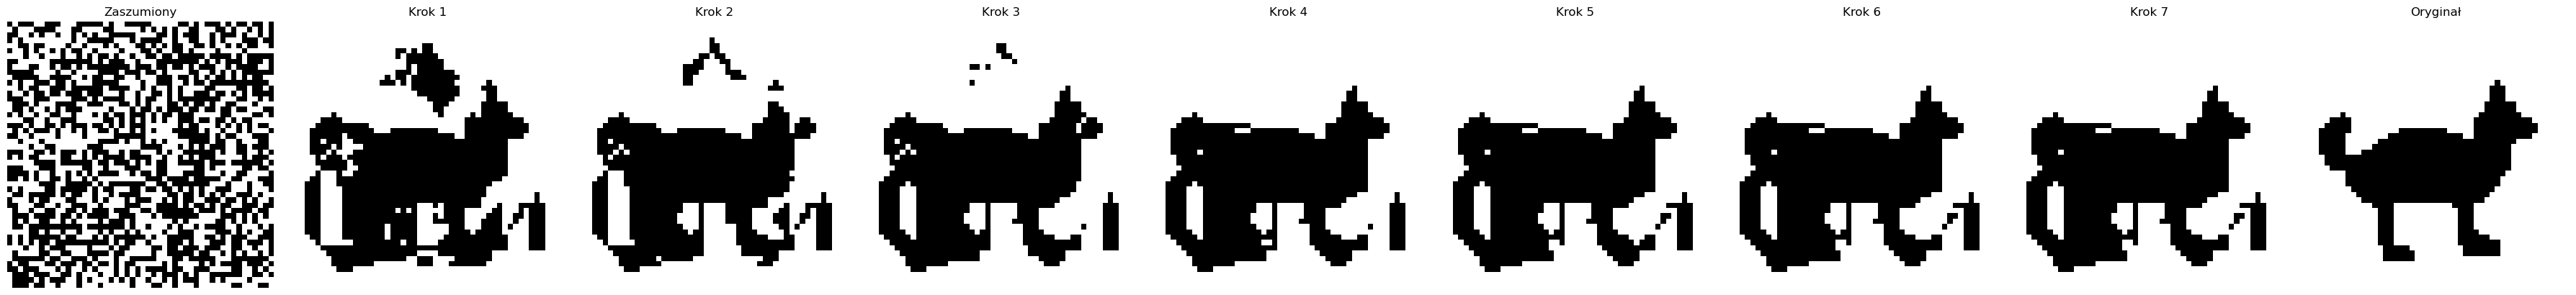

In [21]:
denoised, history = denoise(
    noisy,
    weights,
    bias
)

cols = len(history) + 1

fig, axes = plt.subplots(
    1,
    cols,
    figsize=(4 * cols, 4)
)

for i, img in enumerate(history):

    axes[i].imshow(
        img.reshape(SIZE, SIZE),
        cmap="gray",
        vmin=-1,
        vmax=1
    )

    if i == 0:
        axes[i].set_title("Zaszumiony")
    else:
        axes[i].set_title(f"Krok {i}")

    axes[i].axis("off")

axes[-1].imshow(
    test_img.reshape(SIZE, SIZE),
    cmap="gray",
    vmin=-1,
    vmax=1
)

axes[-1].set_title("Oryginał")

axes[-1].axis("off")

plt.tight_layout()

plt.show()